Implementing a GPT model from Scratch To Generate Text 

![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/OEBPS/Images/4-1.png)
#####  Figure 4.1  The three main stages of coding an LLM. This chapter focuses on step 3 of stage 1: implementing the LLM architecture.

## 4.1 Coding an LLM architecture

- Chapter 1 discussed models like GPT and Llama, which generate words sequentially and are based on the decoder part of the original transformer architecture
- Therefore, these LLMs are often referred to as "decoder-like" LLMs
- Compared to conventional deep learning models, LLMs are larger, mainly due to their vast number of parameters, not the amount of code
- We'll see that many elements are repeated in an LLM's architecture

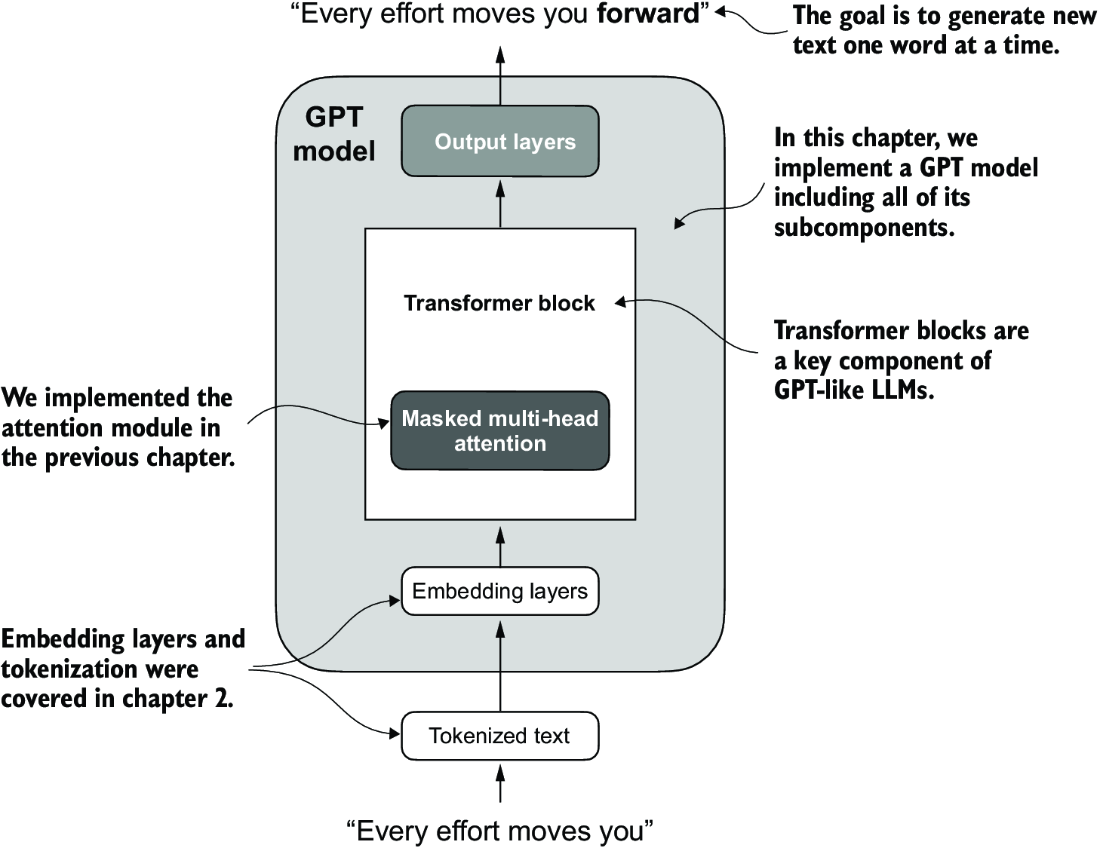

##### Figure 4.2 A GPT model. In addition to the embedding layers, it consists of one or more transformer blocks containing the masked multi-head attention module we previously implemented.

### **GPT-2 vs. GPT-3: **  

#### **Model Architecture & Parameters**  
- Both models share the same **transformer-based architecture**.  
- **GPT-2**: 1.5 billion parameters.  
- **GPT-3**: 175 billion parameters (much larger and more powerful).  

#### **Training & Computational Requirements**  
- **GPT-3 requires massive computing power**:  
  - **355 years** to train on a single **V100 GPU**.  
  - **665 years** on a **consumer RTX 8000 GPU**.  
- GPT-2 is lightweight and can run on a **single laptop**.  
- GPT-3 requires a **GPU cluster** for training and inference.  

#### **Availability & Accessibility**  
- **GPT-2 weights are publicly available** (can be used for research and learning).  
- **GPT-3 weights are not publicly released**.  

#### **Best Choice for Learning**  
- **GPT-2 is ideal for beginners** wanting to understand LLMs.  
- Can be implemented and fine-tuned on **consumer hardware**.  
- GPT-3 is more advanced but **inaccessible for personal use**.  



- Configuration details for the 124 million parameter GPT-2 model include:

In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

- We use short variable names to avoid long lines of code later
- `"vocab_size"` indicates a vocabulary size of 50,257 words, supported by the BPE tokenizer discussed in Chapter 2
- `"context_length"` represents the model's maximum input token count, as enabled by positional embeddings covered in Chapter 2
- `"emb_dim"` is the embedding size for token inputs, converting each input token into a 768-dimensional vector
- `"n_heads"` is the number of attention heads in the multi-head attention mechanism implemented in Chapter 3
- `"n_layers"` is the number of transformer blocks within the model, which we'll implement in upcoming sections
- `"drop_rate"` is the dropout mechanism's intensity, discussed in Chapter 3; 0.1 means dropping 10% of hidden units during training to mitigate overfitting
- `"qkv_bias"` decides if the `Linear` layers in the multi-head attention mechanism (from Chapter 3) should include a bias vector when computing query (Q), key (K), and value (V) tensors; we'll disable this option, which is standard practice in modern LLMs; however, we'll revisit this later when loading pretrained GPT-2 weights from OpenAI into our reimplementation in chapter 5


![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/OEBPS/Images/4-3.png)

##### Figure 4.3  The order in which we code the GPT architecture. We start with the GPT backbone, a placeholder architecture, before getting to the individual core pieces and eventually assembling them in a transformer block for the final GPT architecture.

### **Summary: DummyGPTModel (Simplified GPT Model in PyTorch)**  

- **DummyGPTModel** is a **basic GPT-like model** implemented using PyTorch’s `nn.Module`.  
- **Model Components**:  
  - **Token & positional embeddings** for input representation.  
  - **Dropout layer** for regularization.  
  - **Series of transformer blocks** (`DummyTransformerBlock`).  
  - **Layer normalization** (`DummyLayerNorm`).  
  - **Linear output layer** (`out_head`) for generating logits.  
- **Configuration** is passed via a Python dictionary (e.g., `GPT_CONFIG_124M`).  
- **Forward Method Workflow**:  
  - Computes **token & positional embeddings** for input.  
  - Applies **dropout** for regularization.  
  - Processes input through **transformer blocks**.  
  - Applies **layer normalization**.  
  - Produces **logits** via the final **linear output layer**.  
- The code is **functional**, but **placeholder classes (`DummyLayerNorm` & `DummyTransformerBlock`)** are used and will be developed later.

In [2]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/OEBPS/Images/4-4.png)
#####  Figure 4.4  A big-picture overview showing how the input data is tokenized, embedded, and fed to the GPT model. Note that in our  `DummyGPTClass`  coded earlier, the token embedding is handled inside the GPT model. In LLMs, the embedded input token dimension typically matches the output dimension. The output embeddings here represent the context vectors

In [3]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [4]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)


### **Summary: Output Tensor & Token Embeddings**  

- **Output Tensor Structure**:  
  - Contains **two rows**, each corresponding to a **text sample**.  
  - Each text sample consists of **four tokens**.  
  - Each token is represented as a **50,257-dimensional vector**.  

- **Why 50,257 Dimensions?**  
  - Matches the **size of the tokenizer’s vocabulary**.  
  - Each dimension represents a **unique token** in the vocabulary.  

- **Postprocessing**:  
  - Convert **50,257-dimensional vectors** back into **token IDs**.  
  - Decode token IDs into **readable words**.  

- **Next Steps**:  
  - Implement a **real layer normalization class** to replace `DummyLayerNorm`.  
  - Continue refining GPT architecture with individual components.

---

**Note**

- If you are running this code on Windows or Linux, the resulting values above may look like as follows:
    
```
Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)
```

- Since these are just random numbers, this is not a reason for concern, and you can proceed with the remainder of the chapter without issues
- One possible reason for this discrepancy is the differing behavior of `nn.Dropout` across operating systems, depending on how PyTorch was compiled, as discussed [here on the PyTorch issue tracker](https://github.com/pytorch/pytorch/issues/121595)

---

## 4.2 Normalizing activations with layer normalization

**1. The Core Problem: Unstable Training in Deep Networks**

*   **Issue:** Deep neural networks (many layers) often suffer from *vanishing* or *exploding gradients*.
*   **Vanishing Gradients:** Gradients become extremely small, preventing weights from updating effectively.  Think of it like trying to climb a mountain with incredibly tiny steps – you'll barely move.
    *   **Remember:** loss function helps to predict accurately.
*   **Exploding Gradients:** Gradients become extremely large, causing unstable weight updates (overshooting). Imagine trying to climb a mountain with giant leaps – you might jump right over the peak!
    *   **Remember:** loss function helps to predict accurately.
*   **Consequence:** Slow or unstable training, the network struggles to learn, and poor performance.
*  learning process struggles to find a set of parameters (weights) for the neural network that minimizes the loss function.

**2. Layer Normalization: The Solution**

*   **Goal:** Stabilize and speed up training by normalizing activations *within* each layer.
*   **Normalization:** Adjusting the outputs (activations) of a layer to have:
    *   **Mean of 0:** Centering the data.
    *   **Variance of 1 (Unit Variance):** Scaling the data to a consistent range. Standardizing.
*   **Placement in GPT-2 (and similar transformers):**
    *   *Before* and *after* the Multi-Head Attention module.
    *   *Before* the final output layer.

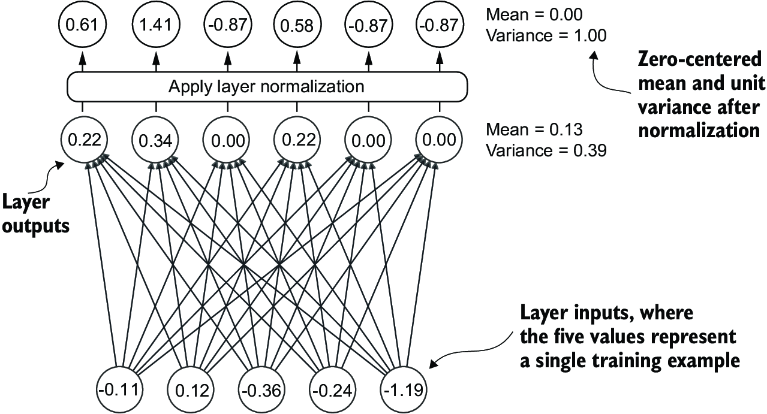
##### Figure 4.5 An illustration of layer normalization where the six outputs of the layer, also called activations, are normalized such that they have a 0 mean and a variance of 1.

Let's break it down step by step using the **`tensor = torch.randn(2, 3, 4)`** example.

---

### **Step 1: Understanding the Tensor Shape**
```python

```
- The **shape** `(2, 3, 4)` means:
  - `2`: **Batch size** (number of samples)
  - `3`: **Number of tokens** (e.g., words in a sentence)
  - `4`: **Feature dimensions** (embedding or hidden state size)


In [23]:
import torch

# Creating a random tensor with shape (2, 3, 4)
tensor = torch.randn(2, 3, 4)

print("Tensor Shape:", tensor.shape)
print("Tensor:\n", tensor)

Tensor Shape: torch.Size([2, 3, 4])
Tensor:
 tensor([[[-1.2203,  1.3139,  1.0533,  0.1388],
         [-0.2044, -2.2685, -0.9133, -0.4204],
         [ 0.2436, -0.0567,  0.3784,  1.6863]],

        [[ 0.2553, -0.5496,  1.0042,  0.8272],
         [ 1.5434,  0.1406,  1.0617, -0.9929],
         [-1.6025, -1.0764,  0.9031, -0.7218]]])


In [35]:
np.mean([-1.22,0.25])

-0.485

In [ ]:
mean_dim0 = tensor.mean(dim=0, keepdim=True)  # Across batch  Calcauate across each index (0,0), (1,1), (2,2)
mean_dim0, mean_dim0.shape

(tensor([[[-0.4825,  0.3821,  1.0288,  0.4830],
          [ 0.6695, -1.0640,  0.0742, -0.7066],
          [-0.6794, -0.5666,  0.6408,  0.4822]]]),
 torch.Size([1, 3, 4]))

In [ ]:
mean_dim1 = tensor.mean(dim=1, keepdim=True)  # Across tokens column
mean_dim1, mean_dim1.shape

(tensor([[[-0.3937, -0.3371,  0.1728,  0.4682]],
 
         [[ 0.0654, -0.4951,  0.9897, -0.2958]]]),
 torch.Size([2, 1, 4]))

In [ ]:


mean_dim2 = tensor.mean(dim=2, keepdim=True)  # Across feature dimensions Row wise
mean_dim2,mean_dim2.shape

(tensor([[[ 0.3214],
          [-0.9517],
          [ 0.5629]],
 
         [[ 0.3843],
          [ 0.4382],
          [-0.6244]]]),
 torch.Size([2, 3, 1]))

In [34]:
import numpy as np
np.mean([-1.2203,  1.3139,  1.0533,  0.1388])

0.321425

### **Step 2: Applying Operations on Different `dim` Values**
#### **(1) Compute the Mean Along Different Dimensions**
We calculate the **mean** along different axes using `dim`.



#### **(2) Interpreting the Results**
##### **Case 1: `dim=0` → Reduce Across Batches**
```python
mean_dim0 = tensor.mean(dim=0, keepdim=True)
print("Mean across batches:\n", mean_dim0)
```
- Reduces **batch size (2) → 1** (averages the two batches).
- Keeps shape as **(1, 3, 4)** (since `keepdim=True`).

##### **Case 2: `dim=1` → Reduce Across Tokens**
```python
mean_dim1 = tensor.mean(dim=1, keepdim=True)
print("Mean across tokens:\n", mean_dim1)
```
- Reduces **tokens (3) → 1** (averages across words for each batch).
- Keeps shape as **(2, 1, 4)**.

##### **Case 3: `dim=2` → Reduce Across Features**
```python
mean_dim2 = tensor.mean(dim=2, keepdim=True)
print("Mean across feature dimensions:\n", mean_dim2)
```
- Reduces **feature dimensions (4) → 1** (averages the features).
- Keeps shape as **(2, 3, 1)**.

---






### **Step 3: Comparison of `keepdim=True` vs `keepdim=False`**
If we set `keepdim=False`, the reduced dimension is **removed** instead of being kept.

```python
mean_no_keepdim = tensor.mean(dim=2, keepdim=False)
print("Mean without keepdim:\n", mean_no_keepdim.shape)
```
#### **Output Shape**
```
keepdim=True → (2, 3, 1)
keepdim=False → (2, 3)  # Last dimension removed
```

---

### **Key Takeaways**
- **`dim=0`** → Aggregates across **batches** (removes batch variability).
- **`dim=1`** → Aggregates across **tokens** (useful for sentence-level processing).
- **`dim=2`** → Aggregates across **features** (normalizing embeddings).
- **`keepdim=True`** ensures the shape remains compatible for further computations.
- **`keepdim=False`** reduces the tensor dimensions, making it more compact.

Using **`dim=-1` (last dimension)** is a common best practice in deep learning for handling dynamic tensor shapes. 🚀

- Let's see how layer normalization works by passing a small input sample through a simple neural network layer:

In [5]:
torch.manual_seed(123)

# create 2 training examples with 5 dimensions (features) each
batch_example = torch.randn(2, 5) 

layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


- Let's compute the mean and variance for each of the 2 inputs above:

In [6]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


    *   **`batch_example`:** Represents a mini-batch of input data.  The shape `(2, 5)` means 2 samples, each with 5 features.
    *   **`nn.Linear(5, 6)`:** A fully connected (linear) layer that transforms 5 input features into 6 output features.
    *   **`nn.ReLU()`:**  The Rectified Linear Unit activation function.  It simply sets negative values to 0.  (`max(0, x)`)
    *   **`out`:**  The activations *before* normalization.  These are the raw outputs of the layer.

- The normalization is applied to each of the two inputs (rows) independently; using dim=-1 applies the calculation across the last dimension (in this case, the feature dimension) instead of the row dimension

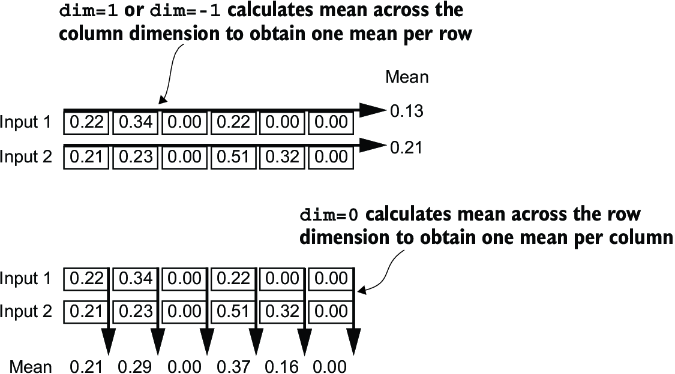

##### Figure 4.6 An illustration of the dim parameter when calculating the mean of a tensor. For instance, if we have a two-dimensional tensor (matrix) with dimensions` [rows, columns]`, using `dim=0 will perform the operation across rows (vertically, as shown at the bottom)`, resulting in an output that aggregates the data for each column. Using `dim=1 or dim=-1 will perform the operation across columns (horizontally, as shown at the top)`, resulting in an output aggregating the data for each row.

- Subtracting the mean and dividing by the square-root of the variance (standard deviation) centers the inputs to have a mean of 0 and a variance of 1 across the column (feature) dimension:

*   **`dim=-1` (or `dim=1` for 2D tensors):** This is *crucial*. It specifies that we calculate the mean and variance *across the last dimension* (the features/embedding dimension).  We normalize *each input example independently*.
*   **`keepdim=True`:** Keeps the output tensor with the same number of dimensions as the input.  This is important for broadcasting in the next step.  Instead of `[mean1, mean2]`, we get `[[mean1], [mean2]]`.
*   **Result:** We see that the mean and variance are *not* 0 and 1 before normalization.

In [7]:
out_norm = (out - mean) / torch.sqrt(var)
print("Normalized layer outputs:\n", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


- Each input is centered at 0 and has a unit variance of 1; to improve readability, we can disable PyTorch's scientific notation:

In [8]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    0.0000],
        [    0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


- Above, we normalized the features of each input
- Now, using the same idea, we can implement a `LayerNorm` class:

In [9]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

**Scale and shift**

- Note that in addition to performing the normalization by subtracting the mean and dividing by the variance, we added two trainable parameters, a `scale` and a `shift` parameter
- The initial `scale` (multiplying by 1) and `shift` (adding 0) values don't have any effect; however, `scale` and `shift` are trainable parameters that the LLM automatically adjusts during training if it is determined that doing so would improve the model's performance on its training task
- This allows the model to learn appropriate scaling and shifting that best suit the data it is processing
- Note that we also add a smaller value (`eps`) before computing the square root of the variance; this is to avoid division-by-zero errors if the variance is 0

**Biased variance**
- In the variance calculation above, setting `unbiased=False` means using the formula $\frac{\sum_i (x_i - \bar{x})^2}{n}$ to compute the variance where n is the sample size (here, the number of features or columns); this formula does not include Bessel's correction (which uses `n-1` in the denominator), thus providing a biased estimate of the variance 
- For LLMs, where the embedding dimension `n` is very large, the difference between using n and `n-1`
 is negligible
- However, GPT-2 was trained with a biased variance in the normalization layers, which is why we also adopted this setting for compatibility reasons with the pretrained weights that we will load in later chapters

- Let's now try out `LayerNorm` in practice:

*   **Layer Normalization vs. Batch Normalization:**
    *   **Batch Normalization:** Normalizes *across the batch dimension*.  This means the statistics (mean and variance) are calculated for the entire batch.
    *   **Layer Normalization:** Normalizes *across the feature dimension*.  Statistics are calculated for *each individual input*.
    *   **Advantages of Layer Normalization:**
        *   **Batch Size Independence:** Works well with small batch sizes and is more stable during distributed training.  This is a major advantage in LLMs, which often have limited batch sizes due to computational constraints.
        *   **Recurrent Networks:** Better suited for recurrent networks (though not directly discussed in this text, it's a common interview point).



# Comparison: Layer Normalization vs. Batch Normalization

| Feature               | Layer Normalization                                   | Batch Normalization                                |
|-----------------------|-----------------------------------------------------|--------------------------------------------------|
| **Normalization Axis** | Across feature dimensions (last axis)               | Across batch dimension (first axis)             |
| **Computation**        | Normalizes each sample independently                | Normalizes using batch statistics               |
| **Dependency on Batch Size** | Works independently of batch size            | Requires a sufficiently large batch size        |
| **Use Case**           | Suitable for NLP models (e.g., Transformers, GPT) and RNNs | Common in CNNs and traditional deep networks   |
| **Effect on Training** | Provides stability across varying batch sizes       | Can lead to instability if batch size is too small |
| **Computational Cost** | Less overhead, efficient in distributed training    | Additional computation for batch statistics     |
| **Adaptability**       | Works well with variable-length sequences           | Requires fixed-size batches for stable statistics |
| **Where Applied**      | Before/after multi-head attention & feed-forward layers | Applied between layers in CNNs & MLPs         |
| **Formulation**        | Normalizes across the last dimension (dim=-1)       | Normalizes across batch (dim=0)                 |


In [21]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)

In [22]:
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)

print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    -0.0000],
        [     0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


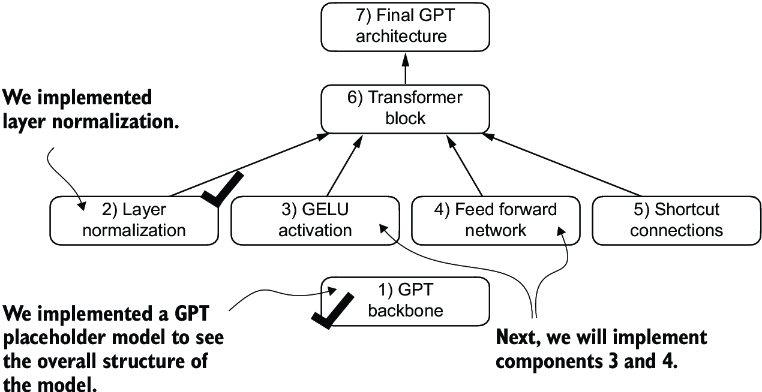

##### Figure 4.7 The building blocks necessary to build the GPT architecture. So far, we have completed the GPT backbone and layer normalization. Next, we will focus on GELU activation and the feed forward network.

## 4.3 Implementing a feed forward network with GELU activations

#### **Key Points:**  
- **GELU Activation** is used in transformer blocks of LLMs instead of traditional ReLU.  
- **Why Not ReLU?**  
  - ReLU is simple and widely used but has sharp discontinuities at zero.  
  - It outputs zero for negative inputs, limiting neuron contribution.  
- **Why GELU?**  
  - A smooth, nonlinear function incorporating Gaussian properties.  
  - Allows small nonzero outputs for negative inputs, aiding training.  
  - Improves optimization in deep networks.  

#### **Comparison of ReLU and GELU:**  

| Feature       | ReLU                      | GELU                          |
|--------------|--------------------------|------------------------------|
| **Formula**  | $$ \max(0, x) $$          | $$ x \cdot \Phi(x) $$ (Gaussian CDF) |
| **Smoothness** | Discontinuous at zero   | Smooth, continuous function  |
| **Negative Input** | Outputs zero        | Outputs small nonzero values |
| **Optimization** | Can slow training due to sharp zero-point | Easier optimization in deep networks |


- GELU ([Hendrycks and Gimpel 2016](https://arxiv.org/abs/1606.08415)) can be implemented in several ways; the exact version is defined as GELU(x)=x⋅Φ(x), where Φ(x) is the cumulative distribution function of the standard Gaussian distribution.
- In practice, it's common to implement a computationally cheaper approximation: $\text{GELU}(x) \approx 0.5 \cdot x \cdot \left(1 + \tanh\left[\sqrt{\frac{2}{\pi}} \cdot \left(x + 0.044715 \cdot x^3\right)\right]\right)
$ (the original GPT-2 model was also trained with this approximation)

In [12]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

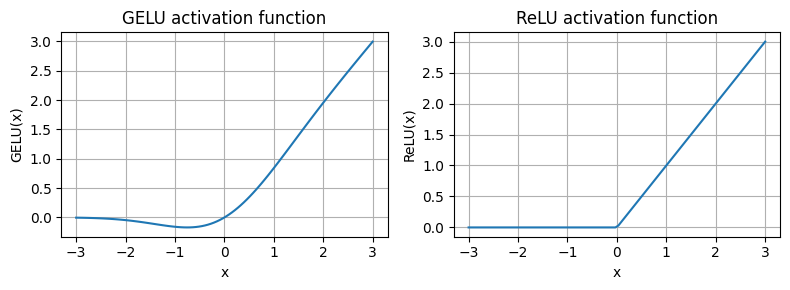

In [13]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Some sample data
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

- As we can see, ReLU is a piecewise linear function that outputs the input directly if it is positive; otherwise, it outputs zero
- GELU is a smooth, non-linear function that approximates ReLU but with a non-zero gradient for negative values (except at approximately -0.75)

- Next, let's implement the small neural network module, `FeedForward`, that we will be using in the LLM's transformer block later:

In [14]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [15]:
print(GPT_CONFIG_124M["emb_dim"])

768


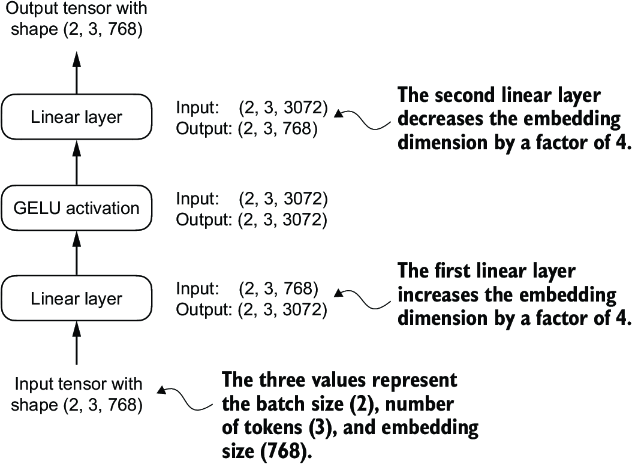

#### Figure 4.9 An overview of the connections between the layers of the feed forward neural network. This neural network can accommodate variable batch sizes and numbers of tokens in the input. However, the embedding size for each token is determined and fixed when initializing the weights.

In [16]:
ffn = FeedForward(GPT_CONFIG_124M)

# input shape: [batch_size, num_token, emb_size]
x = torch.rand(2, 3, 768) 
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


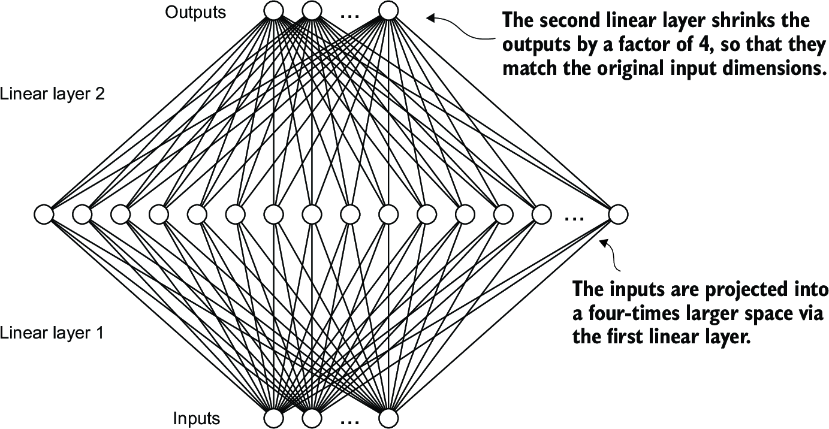

Figure 4.10 An illustration of the expansion and contraction of the layer outputs in the feed forward neural network. First, the inputs expand by a factor of 4 from 768 to 3,072 values. Then, the second layer compresses the 3,072 values back into a 768-dimensional representation.

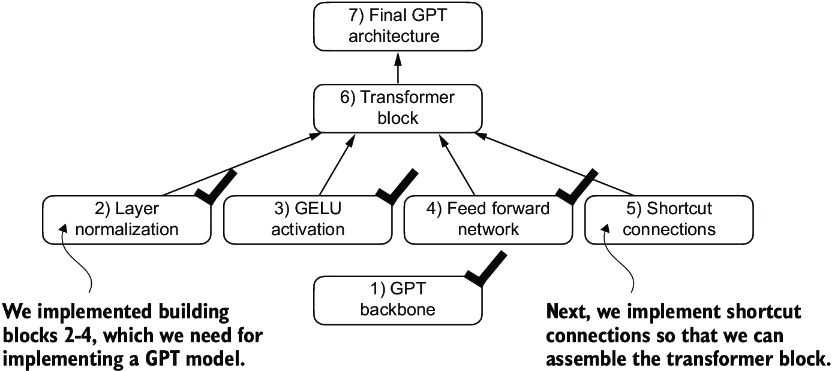

## 4.4 Adding shortcut connections

### **4.4 Adding Shortcut Connections - **  

#### **Key Concepts:**  
- **Shortcut (Skip/Residual) Connections**  
  - Introduced in deep networks (e.g., ResNets) to address the **vanishing gradient problem**.  
  - Allow gradients to flow more effectively during backpropagation.  
  - Improve training of deeper networks.  

- **Vanishing Gradient Problem**  
  - Gradients become smaller as they move backward, making earlier layers hard to train.  
  - Leads to slow convergence and poor performance in deep networks.  

- **How Shortcut Connections Work**  
  - **Create an alternative path** for gradients by skipping layers.  
  - The input of a layer is **added** to its output before passing to the next layer.  
  - Helps maintain useful information in deep networks.  

#### **Advantages of Shortcut Connections:**  
| Feature                 | Without Shortcut Connections | With Shortcut Connections |
|-------------------------|----------------------------|--------------------------|
| **Gradient Flow**       | Weak, vanishing gradients  | Strong, stable gradients |
| **Training Stability**  | Hard to train deep layers  | Easier, faster training  |
| **Network Depth**       | Limited by vanishing gradients | Supports very deep networks |
| **Performance**         | Can degrade with depth     | Improved accuracy & efficiency |

- **Shortcut connections help in training deep neural networks efficiently by preventing gradient vanishing.**  
- **Used extensively in LLMs and CNNs (like ResNets) to improve optimization.**  


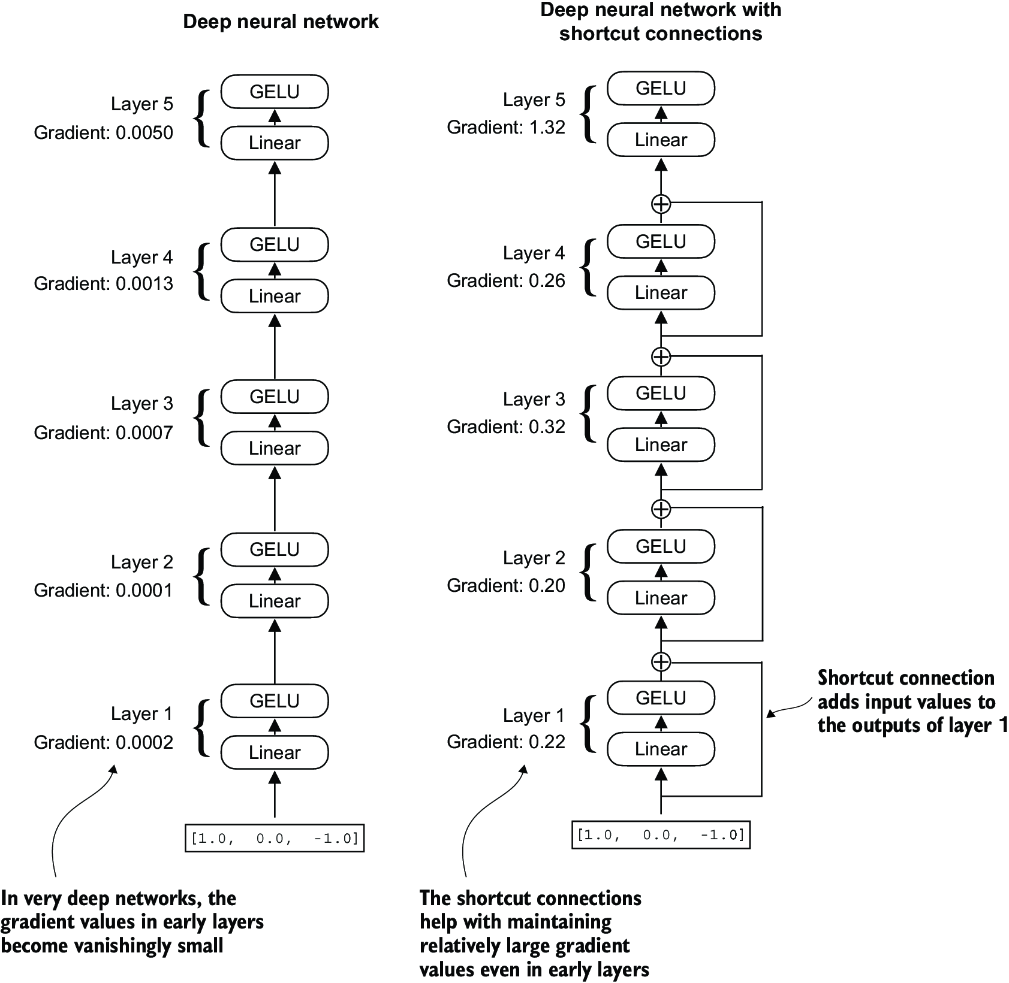

- In code, it looks like this:

In [17]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target
    # and output are
    loss = nn.MSELoss()
    loss = loss(output, target)
    
    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

- Let's print the gradient values first **without** shortcut connections:

In [18]:
layer_sizes = [3, 3, 3, 3, 3, 1]  

sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041653171182
layers.3.0.weight has gradient mean of 0.001398873864673078
layers.4.0.weight has gradient mean of 0.005049646366387606


- Next, let's print the gradient values **with** shortcut connections:

In [19]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732502937317
layers.4.0.weight has gradient mean of 1.3258541822433472


- As we can see based on the output above, shortcut connections prevent the gradients from vanishing in the early layers (towards `layer.0`)
- We will use this concept of a shortcut connection next when we implement a transformer block

## 4.5 Connecting attention and linear layers in a transformer block

- In this section, we now combine the previous concepts into a so-called transformer block
- A transformer block combines the causal multi-head attention module from the previous chapter with the linear layers, the feed forward neural network we implemented in an earlier section
- In addition, the transformer block also uses dropout and shortcut connections

In [36]:

import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True, num_workers=0):
    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

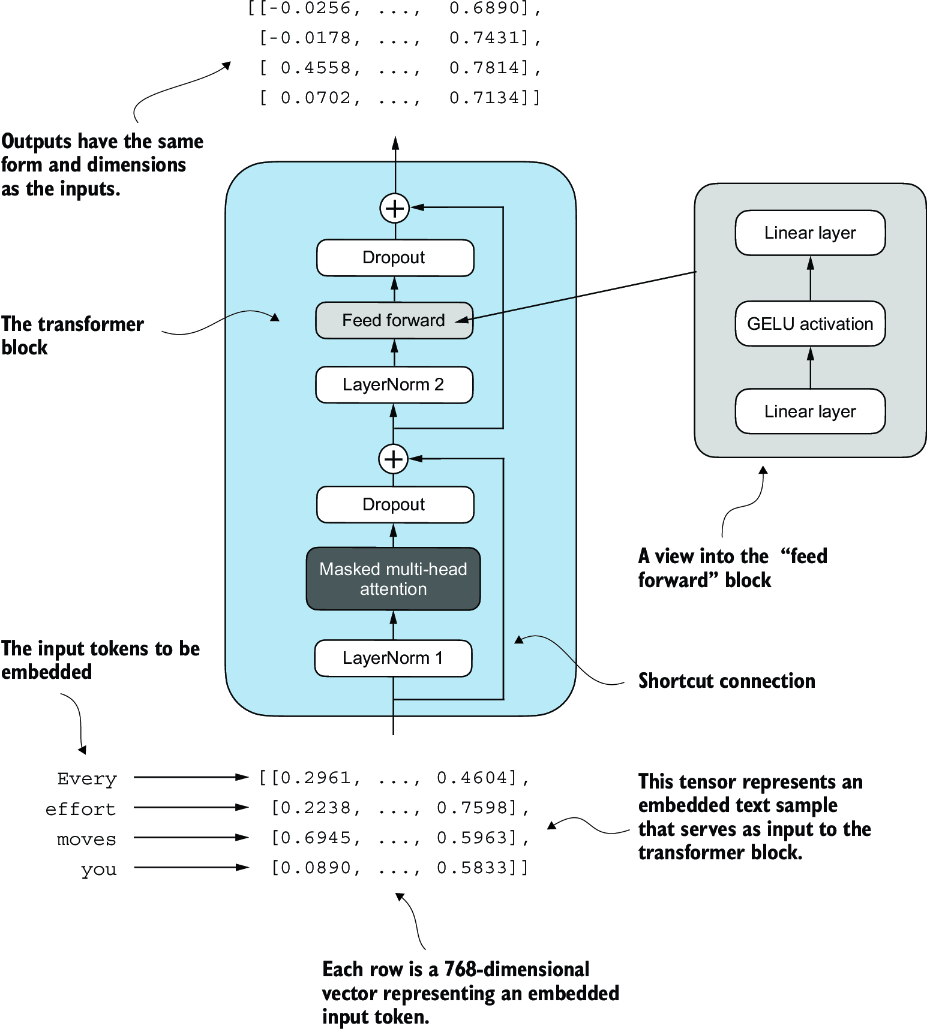

#### An illustration of a transformer block. Input tokens have been embedded into 768-dimensional vectors. Each row corresponds to one token’s vector representation. The outputs of the transformer block are vectors of the same dimension as the input, which can then be fed into subsequent layers in an LLM.

- Suppose we have 2 input samples with 6 tokens each, where each token is a 768-dimensional embedding vector; then this transformer block applies self-attention, followed by linear layers, to produce an output of similar size
- You can think of the output as an augmented version of the context vectors we discussed in the previous chapter

In [ ]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)  # Shape: [batch_size, num_tokens, emb_dim]
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

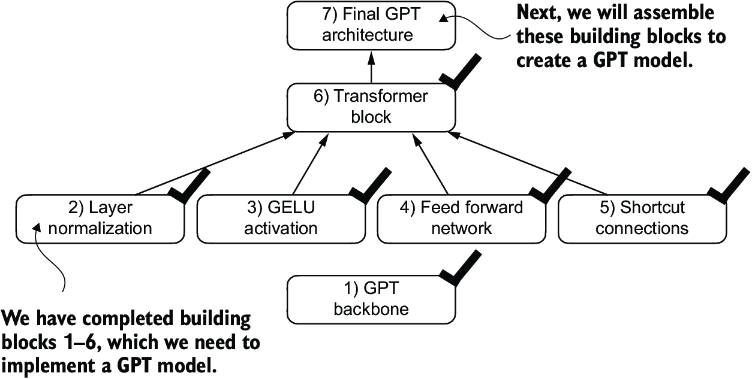

## 4.6 Coding the GPT model

- We are almost there: now let's plug in the transformer block into the architecture we coded at the very beginning of this chapter so that we obtain a usable GPT architecture
- Note that the transformer block is repeated multiple times; in the case of the smallest 124M GPT-2 model, we repeat it 12 times:

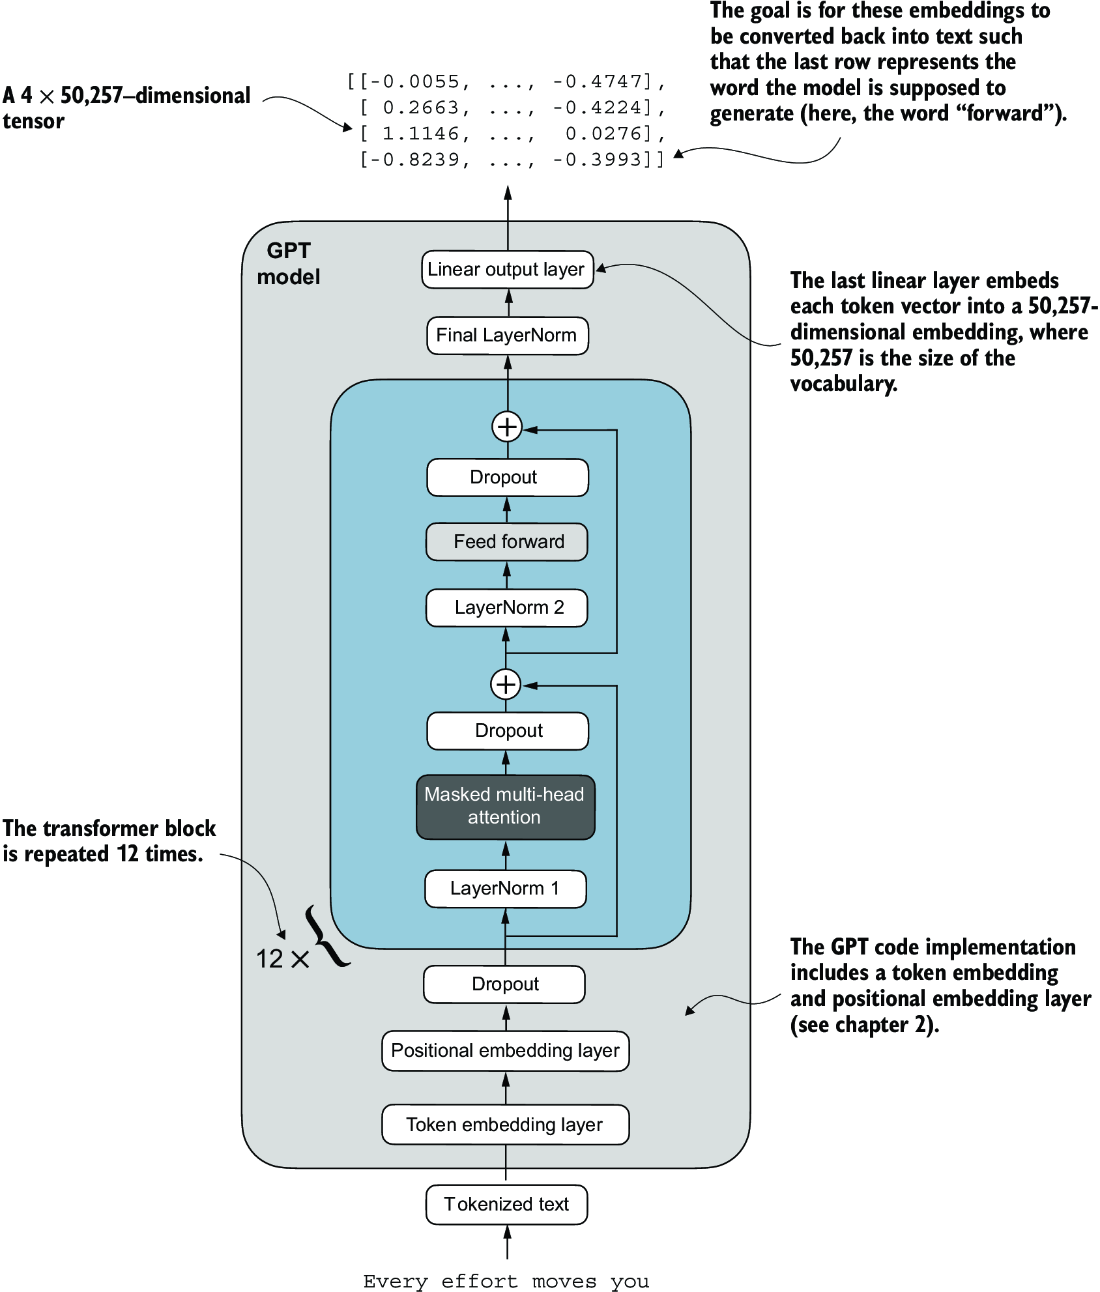

- The corresponding code implementation, where `cfg["n_layers"] = 12`:

In [37]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

- Using the configuration of the 124M parameter model, we can now instantiate this GPT model with random initial weights as follows:

In [38]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.1381,  0.0077, -0.1963,  ..., -0.0222, -0.1060,  0.1717],
         [ 0.3865, -0.8408, -0.6564,  ..., -0.5163,  0.2369, -0.3357],
         [ 0.6989, -0.1829, -0.1631,  ...,  0.1472, -0.6504, -0.0056],
         [-0.4290,  0.1669, -0.1258,  ...,  1.1579,  0.5303, -0.5549]],

        [[ 0.1094, -0.2894, -0.1467,  ..., -0.0557,  0.2911, -0.2824],
         [ 0.0882, -0.3552, -0.3527,  ...,  1.2930,  0.0053,  0.1898],
         [ 0.6091,  0.4702, -0.4094,  ...,  0.7688,  0.3787, -0.1974],
         [-0.0612, -0.0737,  0.4751,  ...,  1.2463, -0.3834,  0.0609]]],
       grad_fn=<UnsafeViewBackward0>)


- We will train this model in the next chapter
- However, a quick note about its size: we previously referred to it as a 124M parameter model; we can double check this number as follows:

In [39]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


- As we see above, this model has 163M, not 124M parameters; why?
- In the original GPT-2 paper, the researchers applied weight tying, which means that they reused the token embedding layer (`tok_emb`) as the output layer, which means setting `self.out_head.weight = self.tok_emb.weight`
- The token embedding layer projects the 50,257-dimensional one-hot encoded input tokens to a 768-dimensional embedding representation
- The output layer projects 768-dimensional embeddings back into a 50,257-dimensional representation so that we can convert these back into words (more about that in the next section)
- So, the embedding and output layer have the same number of weight parameters, as we can see based on the shape of their weight matrices
- However, a quick note about its size: we previously referred to it as a 124M parameter model; we can double check this number as follows:

In [40]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


- In the original GPT-2 paper, the researchers reused the token embedding matrix as an output matrix
- Correspondingly, if we subtracted the number of parameters of the output layer, we'd get a 124M parameter model:

In [41]:
total_params_gpt2 =  total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


- In practice, I found it easier to train the model without `weight-tying`, which is why we didn't implement it here
- However, we will revisit and apply this weight-tying idea later when we load the pretrained weights in chapter 5
- Lastly, we can compute the memory requirements of the model as follows, which can be a helpful reference point:

In [ ]:
# Calculate the total size in bytes (assuming float32, 4 bytes per parameter)
total_size_bytes = total_params * 4

# Convert to megabytes
total_size_mb = total_size_bytes / (1024 * 1024)

print(f"Total size of the model: {total_size_mb:.2f} MB")

- Exercise: you can try the following other configurations, which are referenced in the [GPT-2 paper](https://scholar.google.com/citations?view_op=view_citation&hl=en&user=dOad5HoAAAAJ&citation_for_view=dOad5HoAAAAJ:YsMSGLbcyi4C), as well.

    - **GPT2-small** (the 124M configuration we already implemented):
        - "emb_dim" = 768
        - "n_layers" = 12
        - "n_heads" = 12

    - **GPT2-medium:**
        - "emb_dim" = 1024
        - "n_layers" = 24
        - "n_heads" = 16
    
    - **GPT2-large:**
        - "emb_dim" = 1280
        - "n_layers" = 36
        - "n_heads" = 20
    
    - **GPT2-XL:**
        - "emb_dim" = 1600
        - "n_layers" = 48
        - "n_heads" = 25

## 4.7 Generating text

- LLMs like the GPT model we implemented above are used to generate one word at a time

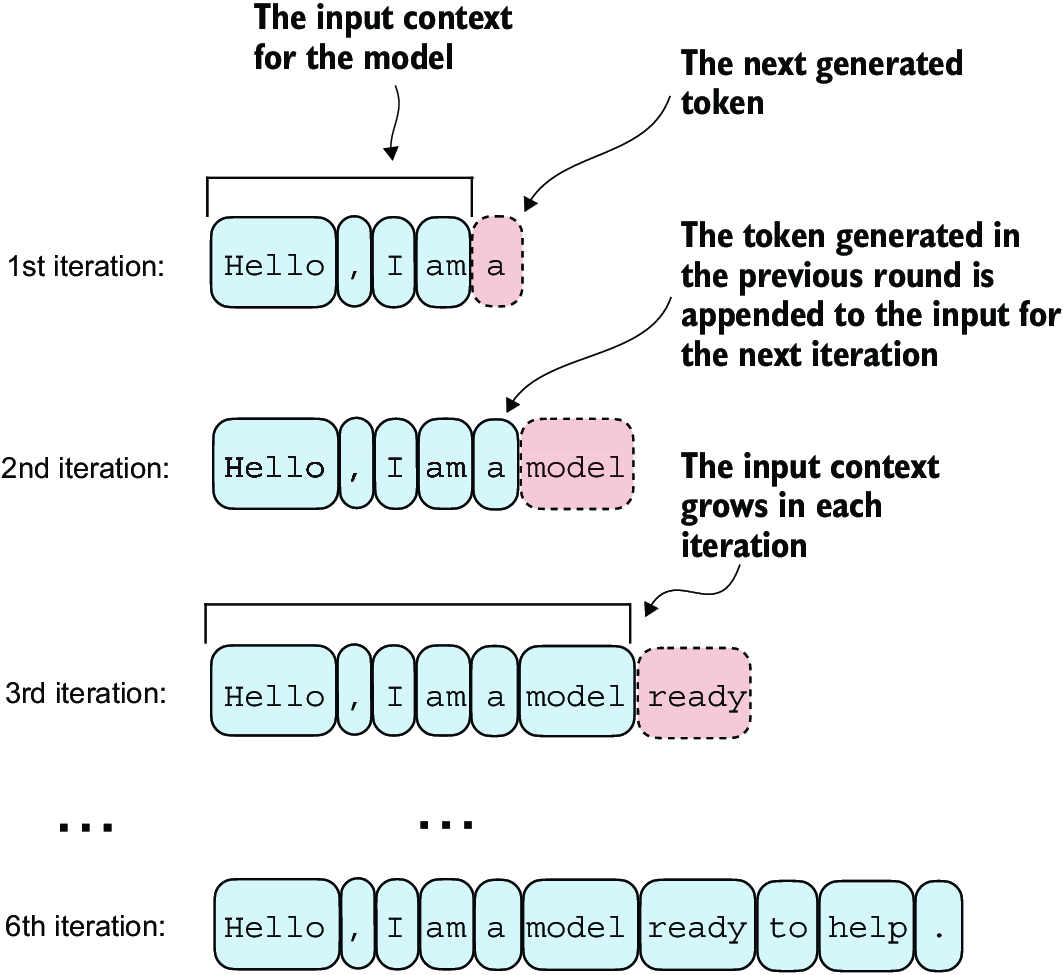

- The following `generate_text_simple` function implements greedy decoding, which is a simple and fast method to generate text
- In greedy decoding, at each step, the model chooses the word (or token) with the highest probability as its next output (the highest logit corresponds to the highest probability, so we technically wouldn't even have to compute the softmax function explicitly)
- In the next chapter, we will implement a more advanced `generate_text` function
- The figure below depicts how the GPT model, given an input context, generates the next word token

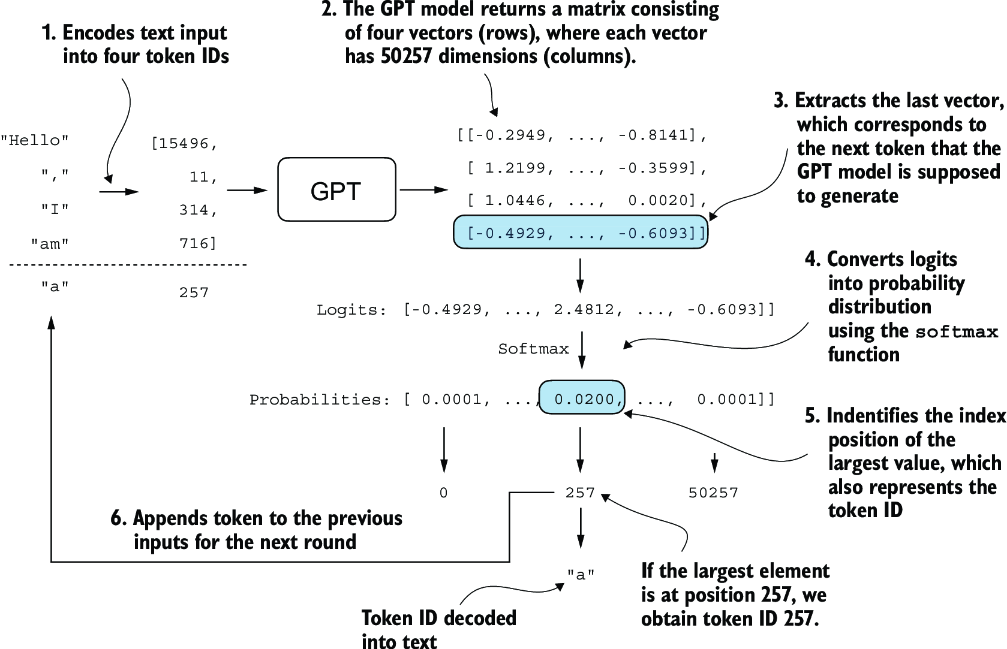

In [44]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

- The `generate_text_simple` above implements an iterative process, where it creates one token at a time

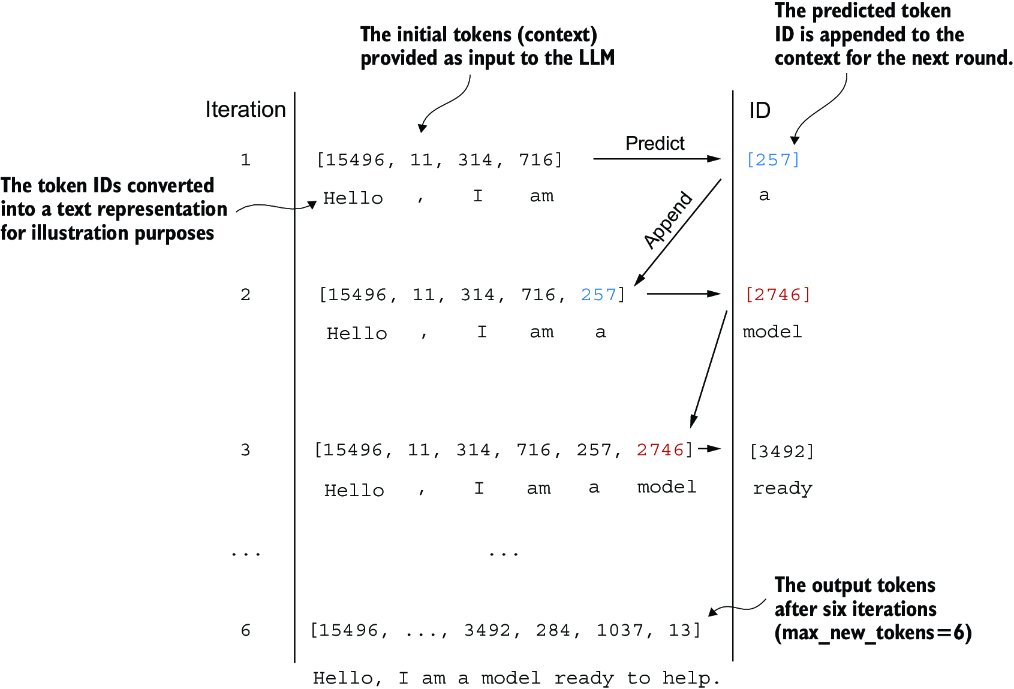

- Let's prepare an input example:

In [45]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("encoded:", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [46]:
model.eval() # disable dropout

out = generate_text_simple(
    model=model,
    idx=encoded_tensor, 
    max_new_tokens=6, 
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


- Remove batch dimension and convert back into text:

In [47]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue



- Note that the model is untrained; hence the random output texts above
- We will train the model in the next chapter